# Real-data experiment 1: relational structure in Fisher iris

This notebook fits a three-component Gaussian mixture to standardized Fisher iris measurements and compares the posterior-similarity complement with BMTS. Species labels are withheld from model fitting, row permutation, covariance estimation, and tolerance selection. They are used only afterward to interpret the learned relations.

The largest-gap rule selects the displayed BMTS tolerance without labels. Set `PAPER_SCALE=True` for the manuscript chain length.


In [1]:
from pathlib import Path
import json
import sys

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "bmts.py").is_file() and (path / "data").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start Jupyter from public/ or public/notebooks/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bmts

bmts.set_notebook_style()
paper = json.loads((ROOT / "data" / "paper_scale_summary.json").read_text())
PAPER_SCALE = False
print(f"Public root located. PAPER_SCALE={PAPER_SCALE}")


Public root located. PAPER_SCALE=False


In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_source = StandardScaler().fit_transform(iris.data)
species_source = iris.target.copy()
species_names = [str(name) for name in iris.target_names]

permutation = np.random.default_rng(5181).permutation(len(X_source))
X = X_source[permutation]
species = species_source[permutation]

initial = KMeans(n_clusters=3, n_init=30, random_state=5179).fit(X)
covariance = bmts.pooled_within_covariance(X, initial.labels_, ridge=1e-3)
settings = (
    {"iterations": 1500, "burn": 600, "thin": 3}
    if PAPER_SCALE
    else {"iterations": 900, "burn": 300, "thin": 6}
)
fit = bmts.sample_common_covariance_gmm(
    X, 3, covariance, seed=5179, initial_labels=initial.labels_,
    concentration=1.0, prior_scale=25.0, **settings,
)
posterior = bmts.posterior_bmts(fit.means, fit.responsibilities)
psm_complement = 1.0 - bmts.rao_blackwell_psm(fit.responsibilities)
entropy = bmts.responsibility_entropy(fit.responsibilities)

upper = np.triu_indices(len(X), k=1)
left, right = species[upper[0]], species[upper[1]]
category_masks = {
    "Within species": left == right,
    "Versicolor–virginica": ((left == 1) & (right == 2)) | ((left == 2) & (right == 1)),
    "Setosa–non-setosa": ((left == 0) & (right != 0)) | ((right == 0) & (left != 0)),
}
tolerance, gap_low, gap_high, gap_width = bmts.largest_gap_threshold(posterior.mean[upper])
relation_probability = (posterior.draws < tolerance).mean(axis=0)
adjacency = relation_probability > 0.8
np.fill_diagonal(adjacency, False)

centered = X - X.mean(axis=0)
_, _, right_vectors = np.linalg.svd(centered, full_matrices=False)
pca = centered @ right_vectors[:2].T

rows = []
for name, mask in category_masks.items():
    pair_index = (upper[0][mask], upper[1][mask])
    rows.append({
        "pair category": name,
        "pairs": int(mask.sum()),
        "mean PSM complement": psm_complement[pair_index].mean(),
        "mean BMTS": posterior.mean[pair_index].mean(),
        "median 90% width": np.median(posterior.width[pair_index]),
        "mean relation probability": relation_probability[pair_index].mean(),
    })
print(f"Retained draws: {fit.n_draws}; label-free tolerance: {tolerance:.3f}")
display(pd.DataFrame(rows).round(3))
paper_study = paper["iris"]
pd.DataFrame({
    "paper-scale category": ["Within species", "Versicolor–virginica", "Setosa–non-setosa"],
    "mean PSM complement": [paper_study[key]["psm_comp_mean"] for key in ("within_species", "versicolor_virginica", "setosa_other")],
    "mean BMTS": [paper_study[key]["bmts_mean"] for key in ("within_species", "versicolor_virginica", "setosa_other")],
    "median 90% width": [paper_study[key]["median_ci_width"] for key in ("within_species", "versicolor_virginica", "setosa_other")],
}).round(3)


Retained draws: 100; label-free tolerance: 2.342


,pair category,pairs,mean PSM complement,mean BMTS,median 90% width,mean relation probability
0,Within species,3675,0.174,0.267,0.109,1.0
1,Versicolor–virginica,2500,0.696,1.154,0.658,1.0
2,Setosa–non-setosa,5000,1.000,3.426,0.428,0.0


,paper-scale category,mean PSM complement,mean BMTS,median 90% width
0,Within species,0.171,0.257,0.084
1,Versicolor–virginica,0.700,1.146,0.632
2,Setosa–non-setosa,1.000,3.423,0.386


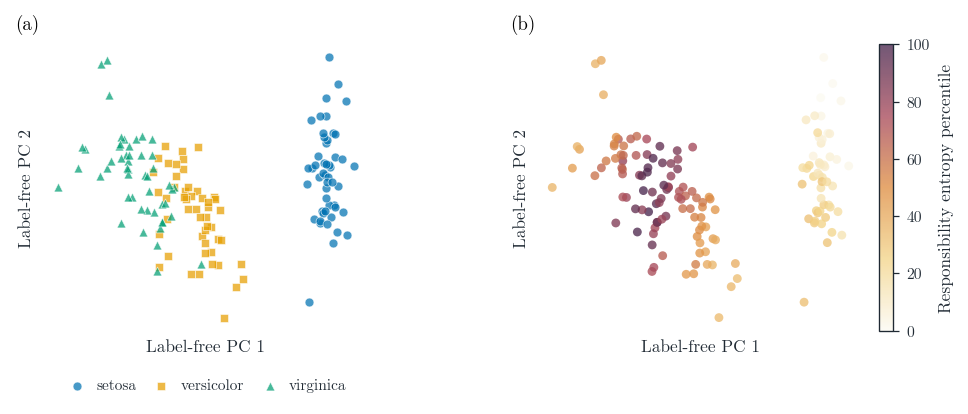

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.65), constrained_layout=True, sharex=True, sharey=True)
for group, name in enumerate(species_names):
    mask = species == group
    axes[0].scatter(
        pca[mask, 0], pca[mask, 1], s=18,
        color=bmts.CATEGORY_COLORS[group], marker=bmts.CATEGORY_MARKERS[group],
        alpha=0.72, edgecolor="white", linewidth=0.35, label=name,
    )
entropy_image = axes[1].scatter(
    pca[:, 0], pca[:, 1], c=100 * bmts.percentile_rank(entropy),
    s=18, cmap=bmts.UNCERTAINTY_CMAP, vmin=0, vmax=100,
    alpha=0.78, edgecolor="none",
)
for index, ax in enumerate(axes):
    ax.set(xlabel="Label-free PC 1", ylabel="Label-free PC 2")
    ax.set_aspect("equal", adjustable="box")
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    bmts.panel_label(ax, f"({chr(97 + index)})")
axes[0].legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.12))
fig.colorbar(entropy_image, ax=axes[1], fraction=0.046, pad=0.035, label="Responsibility entropy percentile")
plt.show()


**Figure 1.** Panel (a) shows the label-free principal-component layout, colored only for post-fit species interpretation. Panel (b) maps posterior responsibility entropy; diffuse responsibilities concentrate near the overlapping versicolor–virginica region.


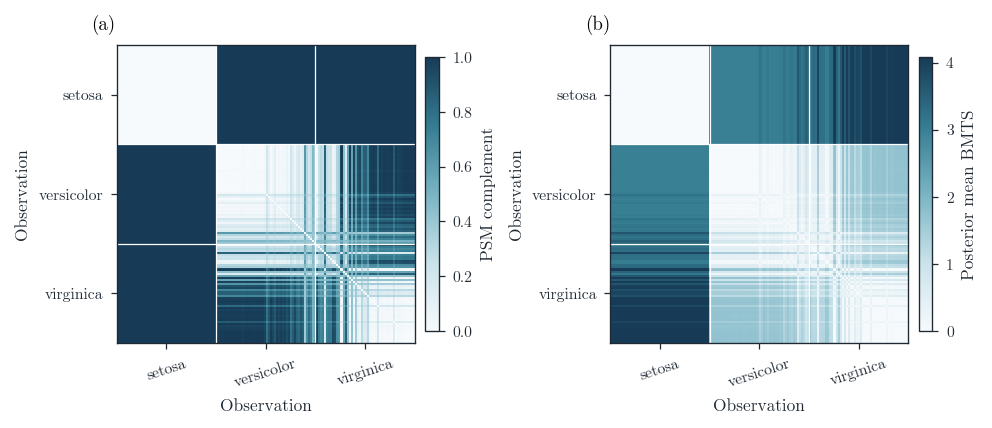

In [4]:
display_order = np.lexsort((X[:, 0], species))
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.85), constrained_layout=True)
for index, (ax, matrix, colorbar_label, vmax) in enumerate([
    (axes[0], psm_complement, "PSM complement", 1.0),
    (axes[1], posterior.mean, "Posterior mean BMTS", None),
]):
    image = ax.imshow(
        matrix[np.ix_(display_order, display_order)], cmap=bmts.SEQUENTIAL_CMAP,
        vmin=0, vmax=vmax, interpolation="nearest",
    )
    for boundary in [50, 100]:
        ax.axhline(boundary - 0.5, color="white", lw=0.6)
        ax.axvline(boundary - 0.5, color="white", lw=0.6)
    ax.set_xticks([24.5, 74.5, 124.5], species_names, rotation=18)
    ax.set_yticks([24.5, 74.5, 124.5], species_names)
    ax.set(xlabel="Observation", ylabel="Observation")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.035, label=colorbar_label)
    bmts.panel_label(ax, f"({chr(97 + index)})")
plt.show()


**Figure 2.** Ordered pairwise summaries. Panel (a) is the posterior-similarity complement; panel (b) is posterior mean BMTS. Species ordering is used only for evaluation and display.


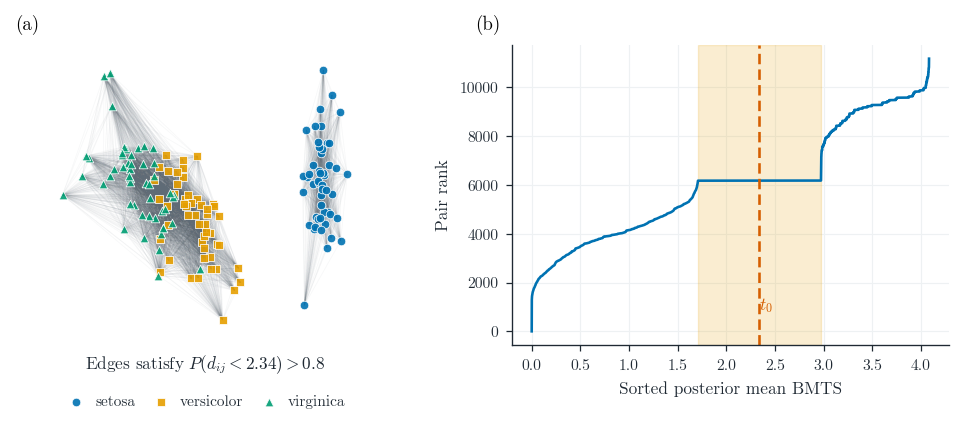

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.75), constrained_layout=True)
bmts.draw_relation_graph(
    axes[0], pca, adjacency, groups=species, group_names=species_names,
    edge_values=relation_probability, edge_alpha=0.12, node_size=17,
)
axes[0].set_xlabel(rf"Edges satisfy $P(d_{{ij}}<{tolerance:.2f})>0.8$")
axes[0].legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, -0.12))
bmts.panel_label(axes[0], "(a)")

values = np.sort(posterior.mean[upper])
axes[1].plot(values, np.arange(len(values)), color=bmts.BLUE)
axes[1].axvline(tolerance, color=bmts.VERMILLION, linestyle=(0, (4, 2)))
axes[1].axvspan(gap_low, gap_high, color=bmts.ORANGE, alpha=0.18)
axes[1].set(xlabel="Sorted posterior mean BMTS", ylabel="Pair rank")
axes[1].text(tolerance, len(values) * 0.08, r"$t_0$", color=bmts.VERMILLION, ha="left")
bmts.finish_axes(axes[1], "both")
bmts.panel_label(axes[1], "(b)")
plt.show()


**Figure 3.** Panel (a) is the posterior relation graph. Panel (b) shows the label-free largest-gap rule used to select its tolerance; the shaded interval is the largest adjacent gap in sorted posterior mean BMTS values.


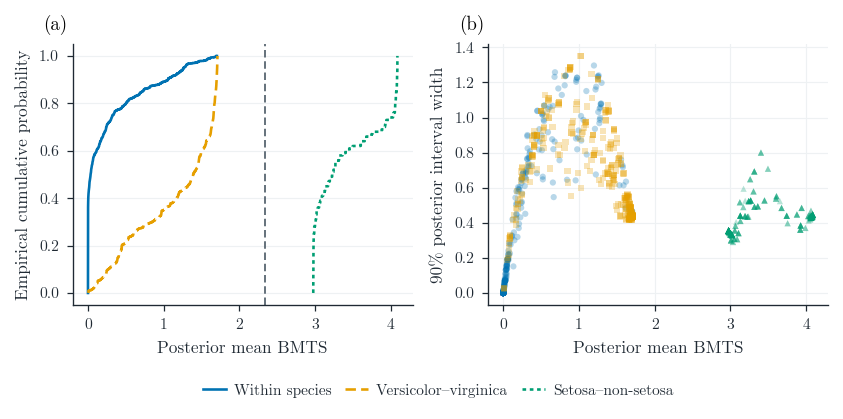

In [6]:
values_by_category = [posterior.mean[upper][mask] for mask in category_masks.values()]
widths_by_category = [posterior.width[upper][mask] for mask in category_masks.values()]
colors = [bmts.BLUE, bmts.ORANGE, bmts.GREEN]
styles = ["-", (0, (4, 2)), (0, (1.4, 1.4))]

fig, axes = plt.subplots(1, 2, figsize=(bmts.TEXT_WIDTH_IN, 2.85), constrained_layout=False)
fig.subplots_adjust(bottom=0.27, wspace=0.22)
handles = []
for values, name, color, style in zip(values_by_category, category_masks, colors, styles):
    x = np.sort(values); y = np.arange(1, len(x) + 1) / len(x)
    handle, = axes[0].step(x, y, where="post", color=color, linestyle=style, label=name)
    handles.append(handle)
axes[0].axvline(tolerance, color=bmts.MUTED, linestyle=(0, (4, 2)), linewidth=0.9)
axes[0].set(xlabel="Posterior mean BMTS", ylabel="Empirical cumulative probability")
bmts.finish_axes(axes[0], "y")
bmts.panel_label(axes[0], "(a)")

scatter_rng = np.random.default_rng(8119)
for values, widths, color, marker in zip(values_by_category, widths_by_category, colors, ["o", "s", "^"]):
    count = min(350, len(values))
    index = scatter_rng.choice(len(values), size=count, replace=False)
    axes[1].scatter(values[index], widths[index], s=9, marker=marker, color=color, alpha=0.28, edgecolor="none")
axes[1].set(xlabel="Posterior mean BMTS", ylabel="90% posterior interval width")
bmts.finish_axes(axes[1], "both")
bmts.panel_label(axes[1], "(b)")
fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, 0.02))
plt.show()


**Figure 4.** Panel (a) compares the BMTS distributions for within-species, versicolor–virginica, and setosa–non-setosa pairs. Panel (b) retains posterior interval width rather than reducing every pair to a point estimate. The learned geometry strongly isolates setosa while representing the versicolor–virginica transition more gradually.
